# 1. Why does mutual information need a neural estimator?

To characterise the relationship between two variables, correlation is cheap to compute and easy to understand and implement with very few caveats and failure modes. Mutual information on the other hand is more expensive, harder to estimate, and comes with far more caveats. This notebook makes the case for paying that cost, and for paying it with a neural estimator.

We'll answer these questions:

1. **The Why:** The reason to consider mutual information in the first place instead of correlations. What does a correlation miss that mutual information catches?
2. **The How I:** Mutual information is not a new quantity, and there are several ways to estimate it. Why not use one of the obvious ones, such as binning?
3. **The How II:** We show how to do that using neural-network-based estimators, and what caveats that choice introduces.

Overall, a neural estimate is a trained quantity, so the number you get depends on how you trained it. Throughout the series, we'll go through what that number means and what makes it defensible.

## Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, spearmanr
import neural_mi as nmi

nmi.set_verbosity('ERROR')

## Cost knobs

The most expensive cell is the KSG sweep in section 3, at its larger sample size.

In [2]:
# --- Cost knobs -----------------------------------------------------------
# All safe: reducing any of these can cost some precision, but not the conclusion.

FOLD_N     = 2_000               # samples for the folded example in sections 1 and 2
FOLD_SIGMA = 0.2                 # noise added to |x|; this is what sets the exact MI
PANEL_BINS = [2, 8, 32]          # bin counts drawn as joint histograms
BIN_COUNTS = [2, 4, 8, 16, 32, 64]  # bin counts swept in one dimension
BIN_NS     = [100, 2_000, 20_000]   # sample sizes for that sweep
BIN_DIMS   = [1, 2, 3, 4]        # independent copies of the pair, section 2's last table
BIN_FIXED  = 32                  # bin count carried into that table

OBSERVED_DIM = 500               # observed channels in the high-dimensional problem
LATENT_DIM   = 10                # shared latent dimensions
MI_TRUE      = 4.0               # bits, by construction
KSG_K        = [3, 5, 10, 20, 40]   # KSG neighbour counts
COMPARE_NS   = [500, 5_000]     # undersampled, well-sampled

SEED = 0

# Quick pass: COMPARE_NS = [500] drops the expensive half of section 3 and
# leaves section 4 with only the starved case. That case cannot show the
# neural estimate recovering the truth when the samples are there.

## 1. Correlation misses what mutual information catches

Take a standard normal $X$, fold it about zero, and add a little noise:

$$Y = |X| + \sigma\,\varepsilon, \qquad
  X \sim \mathcal{N}(0, 1), \quad \varepsilon \sim \mathcal{N}(0, 1).$$

$Y$ is built out of $X$ and nothing else, so $X$ says a great deal about it.
What $Y$ never learns is the sign of $X$. The relation is symmetric about zero,
so the upward half and the downward half of any linear trend cancel exactly.

Since $Y$ depends on $X$ only through $|X|$, we can calculate the density of $Y$ as:

$$p_Y(y) \;=\; 2\,\mathcal{N}\!\left(y \mid 0,\, 1 + \sigma^2\right)\,
              \Phi\!\left(\frac{y}{\sigma\sqrt{1 + \sigma^2}}\right),$$

where $\Phi$ is the standard normal cumulative distribution, so the mutual
information is $I(X; Y) = h(Y) - h(\sigma\varepsilon)$, where the noise entropy is
$h(\sigma\varepsilon) = \tfrac{1}{2}\log_2\!\left(2\pi e \sigma^2\right)$ and
$h(Y)$ comes from integrating the density above. That gives us an exact value
to hold the estimates in this notebook against.

**Note:** You don't need to follow the maths here. $X$ and $Y$ know a lot about each other, but not in a simple linear way.

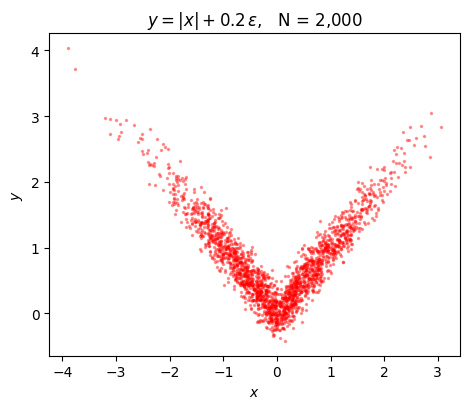

x (2000, 1)   y (2000, 1)   sigma = 0.2
exact I(X; Y)         = 1.5538 bits

Pearson  corr(X, Y)   = -0.0572
Spearman corr(X, Y)   = -0.0359
Pearson  corr(|X|, Y) = +0.9485


In [3]:
def fold_pair(n_samples, dim=1, sigma=None, seed=SEED):
    """X standard normal, Y = |X| + sigma * noise, dim independent copies."""
    sigma = FOLD_SIGMA if sigma is None else sigma
    rng = np.random.default_rng(seed)
    x = rng.standard_normal((n_samples, dim))
    y = np.abs(x) + sigma * rng.standard_normal((n_samples, dim))
    return x, y


def fold_exact_mi(sigma=None, n_grid=200_001):
    """I(X; Y) in bits, by quadrature on the closed-form density of Y."""
    sigma = FOLD_SIGMA if sigma is None else sigma
    s = np.sqrt(1 + sigma ** 2)
    y = np.linspace(-12 * s, 12 * s, n_grid)
    p = 2 * norm.pdf(y, 0, s) * norm.cdf(y / (sigma * s))
    h_y = -np.sum(p * np.log2(np.maximum(p, 1e-300))) * (y[1] - y[0])
    h_noise = 0.5 * np.log2(2 * np.pi * np.e * sigma ** 2)
    return float(h_y - h_noise)


x_fold, y_fold = fold_pair(FOLD_N)
FOLD_MI = fold_exact_mi()

# --- Plot the folded example ------------------------------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.plot(x_fold[:, 0], y_fold[:, 0], '.', ms=3, alpha=0.35, color='r')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title(rf'$y = |x| + {FOLD_SIGMA}\,\varepsilon$,   N = {FOLD_N:,}')
fig.tight_layout()
plt.show()


print(f"x {x_fold.shape}   y {y_fold.shape}   sigma = {FOLD_SIGMA}")
print(f"exact I(X; Y)         = {FOLD_MI:.4f} bits")
print()
print(f"Pearson  corr(X, Y)   = {np.corrcoef(x_fold[:, 0], y_fold[:, 0])[0, 1]:+.4f}")
print(f"Spearman corr(X, Y)   = {spearmanr(x_fold[:, 0], y_fold[:, 0]).statistic:+.4f}")
print(f"Pearson  corr(|X|, Y) = {np.corrcoef(np.abs(x_fold[:, 0]), y_fold[:, 0])[0, 1]:+.4f}")

Both correlation estimates in the first two lines can be obtained by chance at this
sample size. Correlation looks for a straight line and finds that the two arms
cancel. The third line is the same Pearson correlation computed
on the correct parametrisation $|X|$, and it identifies the dependence. The dependence was there all along, visible only to someone who guessed the
transform.

Mutual information is what you reach for when you have no such guess. It asks
how much knowing $x$ narrows down $y$ across any relation at all, linear or nonlinear. Run on this
sample, it should land close to the exact value printed above.

In [4]:
def estimate(x_data, y_data):
    return nmi.run(x_data, y_data, mode='estimate',
                   model=nmi.Model(hidden_dim=128, embedding_dim=32),
                   training=nmi.Training(n_epochs=150, patience=30, learning_rate=1e-3),
                   split=nmi.Split(mode='random'),
                   n_workers=1, seed=SEED, show_progress=True)

t0 = time.time()
fold_res = estimate(x_fold, y_fold)
print(f"NeuralMI mode='estimate'   MI = {fold_res.mi_estimate:.4f} bits   "
      f"(exact {FOLD_MI:.4f}, {time.time() - t0:.1f}s)")

Run e30708a2-b0bb-4395-9a64-afce29a6cb5f_c0:   0%|          | 0/150 [00:00<?, ?it/s]

NeuralMI mode='estimate'   MI = 1.5364 bits   (exact 1.5538, 8.2s)


This is the case for an information measure. A dependence can be strong,
exactly known, and completely invisible to a correlation screen.

Of course, this example is idealised, and you could have guessed the right form directly. In high dimensions, where we can't see beyond pairwise interactions and there may be thousands of them, or when the relationship is not an obvious nonlinearity, that guess isn't available.

The rest of the notebook is about the harder half of the problem. Mutual
information has to be estimated from a finite sample, and that is hard or even impossible in some cases. We'll see below that the two classical
routes are unreliable in modern neuroscience, where we can record thousands of neurons for minutes or hours at most, a regime that leaves the data high-dimensional and undersampled.

## 2. Estimating it by binning

Mutual information is defined as

$$I(X;Y) = \sum_{x}\sum_{y} p(x,y) \log{\frac{p(x,y)}{p(x)p(y)}}$$

It depends on probabilities, effectively counts. The textbook
estimator of a probability is to chop each variable into bins, count how often
each joint or marginal cell is occupied, and plug those frequencies into the
definition. It needs no training and no model, but the choice of bin size introduces problems.

In [5]:
# The estimator is three short functions with equal-frequency bins, so each
# marginal bin holds the same number of points and the marginal entropies come
# out as large as the binning allows.

def quantile_edges(column, n_bins):
    """Equal-frequency bin edges for one column, outer edges at the extremes."""
    interior = np.quantile(column, np.linspace(0, 1, n_bins + 1)[1:-1])
    return np.concatenate([[column.min()], interior, [column.max()]])


def quantile_codes(a, n_bins):
    """Equal-frequency bin index per column."""
    edges = np.quantile(a, np.linspace(0, 1, n_bins + 1)[1:-1], axis=0)
    return np.stack([np.searchsorted(edges[:, j], a[:, j])
                     for j in range(a.shape[1])], axis=1)


def _entropy_bits(codes):
    _, inv = np.unique(codes, axis=0, return_inverse=True)
    counts = np.bincount(inv)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))


def plugin_mi_bits(x, y, n_bins):
    """Plug-in mutual information from a joint histogram, in bits."""
    cx, cy = quantile_codes(x, n_bins), quantile_codes(y, n_bins)
    return (_entropy_bits(cx) + _entropy_bits(cy)
            - _entropy_bits(np.concatenate([cx, cy], axis=1)))

Run it on the same folded sample, at three bin counts, and draw what the
estimator is looking at.

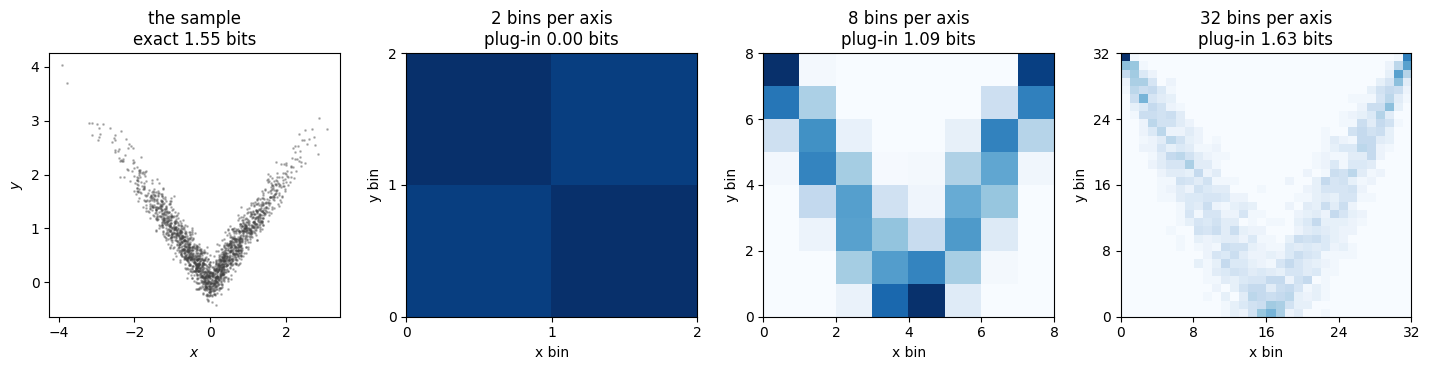

  2 bins per axis:     4 joint cells,  0.0% of them empty,   500.0 points per cell on average
  8 bins per axis:    64 joint cells, 34.4% of them empty,    31.2 points per cell on average
 32 bins per axis: 1,024 joint cells, 57.1% of them empty,     2.0 points per cell on average


In [6]:
fig, axes = plt.subplots(1, 1 + len(PANEL_BINS),
                         figsize=(3.6 * (1 + len(PANEL_BINS)), 3.8))

axes[0].plot(x_fold[:, 0], y_fold[:, 0], '.', ms=2, alpha=0.3, color='0.25')
axes[0].set_title(f'the sample\nexact {FOLD_MI:.2f} bits')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')

empty = {}
for ax, n_bins in zip(axes[1:], PANEL_BINS):
    cx = quantile_codes(x_fold, n_bins)[:, 0]
    cy = quantile_codes(y_fold, n_bins)[:, 0]
    counts = np.zeros((n_bins, n_bins))
    np.add.at(counts, (cx, cy), 1)
    empty[n_bins] = (counts == 0).mean()
    ax.imshow(counts.T, origin='lower', cmap='Blues', aspect='auto',
              vmin=0, vmax=counts.max(), extent=[0, n_bins, 0, n_bins])
    ax.set_xticks(range(0, n_bins + 1, max(1, n_bins // 4)))
    ax.set_yticks(range(0, n_bins + 1, max(1, n_bins // 4)))
    ax.set_xlabel('x bin')
    ax.set_ylabel('y bin')
    ax.set_title(f'{n_bins} bins per axis\nplug-in '
                 f'{plugin_mi_bits(x_fold, y_fold, n_bins):.2f} bits')

fig.tight_layout()
plt.show()

for n_bins in PANEL_BINS:
    print(f"{n_bins:>3} bins per axis: {n_bins ** 2:>5,} joint cells, "
          f"{empty[n_bins]:>5.1%} of them empty, "
          f"{FOLD_N / n_bins ** 2:>7.1f} points per cell on average")

At two bins per axis the picture is flat and the estimate is zero. Correlation
gave the same answer. Two equal-frequency bins on $x$ split the sample at the
median, so all the code keeps about $x$ is its sign. The sign is the one
feature of $x$ that $Y$ was built to discard. A coarse enough grid destroys the
dependence before the counting starts.

At eight bins the V shape is there in the occupancy and the estimate climbs. It stays
below the truth because each cell still smears a range of $x$ against a range
of $y$.

At thirty-two bins the grid has more cells than the sample can populate. The
count printed under the figure says how many are empty, and the occupied ones
hold a point or two each. A table of near-unique rows reports a dependence that
is an artifact of counting.

Sweeping the bin count over three sample sizes shows how far that goes.

In [7]:
count_table = np.zeros((len(BIN_COUNTS), len(BIN_NS)))
for i, n_bins in enumerate(BIN_COUNTS):
    for j, n in enumerate(BIN_NS):
        xg, yg = fold_pair(n)
        count_table[i, j] = plugin_mi_bits(xg, yg, n_bins)

print(f"one dimension each side, exact = {FOLD_MI:.2f} bits")
print(f"{'bins':>5} " + " ".join(f"{'N=' + f'{n:,}':>12}" for n in BIN_NS))
for i, n_bins in enumerate(BIN_COUNTS):
    print(f"{n_bins:>5} " + " ".join(f"{v:>12.2f}" for v in count_table[i]))
print()
print("closest to the truth in each column: "
      + ", ".join(
          f"N={n:,} at {BIN_COUNTS[int(np.argmin(np.abs(count_table[:, j] - FOLD_MI)))]} bins"
          for j, n in enumerate(BIN_NS)))

one dimension each side, exact = 1.55 bits
 bins        N=100      N=2,000     N=20,000
    2         0.02         0.00         0.00
    4         0.57         0.62         0.62
    8         1.20         1.09         1.08
   16         2.01         1.41         1.34
   32         3.48         1.63         1.47
   64         5.22         2.20         1.59

closest to the truth in each column: N=100 at 8 bins, N=2,000 at 32 bins, N=20,000 at 64 bins


The bin count that lands closest to the truth is different in every column, and
it moves down the table as the sample grows. Coarse rows repeat the same value
at every sample size. The discretisation floor does not care how much data you
have. Fine rows start far above the truth, fall towards it slowly, and reach it late or not at all. Choosing the bin count well requires
knowing the answer you are trying to estimate.

That is the one-dimensional version of the problem, and one dimension is the
easy case. The grid has $b$ bins on each axis of each variable, so with $d$
dimensions per side it has

$$b^{\,2d} \quad \text{joint cells},$$

and the sample has to populate every one of them. Keeping the bin count that
worked in one dimension, we stack independent copies of the same folded pair and
count how many points land in a cell on average.

In [8]:
DIM_N = BIN_NS[-1]
occupancy_1d = DIM_N / float(BIN_FIXED) ** 2

print(f"{BIN_FIXED} bins per axis, N = {DIM_N:,}, "
      f"exact = {FOLD_MI:.2f} bits per pair")
print(f"{'dims':>5} {'exact':>7} {'joint cells':>18} {'pts per cell':>13} "
      f"{'N for 1-d occupancy':>21} {'plug-in':>9}")
for d in BIN_DIMS:
    xg, yg = fold_pair(DIM_N, dim=d)
    cells = float(BIN_FIXED) ** (2 * d)
    print(f"{d:>5} {d * FOLD_MI:>7.2f} {cells:>18,.0f} {DIM_N / cells:>13.3g} "
          f"{cells * occupancy_1d:>21.1e} "
          f"{plugin_mi_bits(xg, yg, BIN_FIXED):>9.2f}")
print()
print(f"log2(N) = {np.log2(DIM_N):.1f} bits, the ceiling on what any count "
      f"over {DIM_N:,} samples can report")

32 bins per axis, N = 20,000, exact = 1.55 bits per pair
 dims   exact        joint cells  pts per cell   N for 1-d occupancy   plug-in
    1    1.55              1,024          19.5               2.0e+04      1.47
    2    3.11          1,048,576        0.0191               2.0e+07      5.87


    3    4.66      1,073,741,824      1.86e-05               2.1e+10     13.21
    4    6.22  1,099,511,627,776      1.82e-08               2.1e+13     14.25

log2(N) = 14.3 bits, the ceiling on what any count over 20,000 samples can report


By four dimensions a side the estimate has walked up to its own ceiling and
sits at $\log_2 N$, a value it would report for any data at all. The truth it is
supposed to be tracking is less than half of that. Nothing about the folded
pair got harder; the grid outgrew the sample, and the count started
measuring the grid.

The last column says why collecting more data does not repair this. To hold the
occupancy that made the one-dimensional estimate reasonable, the sample has to
grow as $b^{2d}$, a factor of a thousand per added dimension at this bin count.
A recording with two hundred channels on each side is a four-hundred-dimensional
joint space. There is no bin count and no achievable sample size
that makes a histogram of it mean anything.

## 3. A better classical estimator

The grid was the problem, so the fix is to drop it. KSG
([Kraskov et al., 2004](https://doi.org/10.1103/PhysRevE.69.066138)) is the standard classical choice for continuous variables.
It replaces fixed cells with distances to nearest neighbours, a choice that adapts to the local density and removes the bin-width question outright. In low
dimensions it is very good. There is no free lunch, though. You trade the bin
width for a neighbour count.

We test this on something that resembles the regime of neural recordings. A latent pair is
drawn jointly Gaussian in $d$ dimensions, each dimension correlated with its
partner and with nothing else,

$$\begin{pmatrix} z^{x} \\ z^{y} \end{pmatrix} \;\sim\;
  \mathcal{N}\!\left(0,\;
  \begin{pmatrix} I_d & \rho I_d \\ \rho I_d & I_d \end{pmatrix}\right),
  \qquad I\bigl(z^{x}; z^{y}\bigr) \;=\; -\tfrac{d}{2}\log_2\!\left(1 - \rho^2\right),$$

so setting $\rho = \sqrt{1 - 2^{-2I/d}}$ buys whatever latent value we ask for.
Each half then goes through its own random two-layer network with a softplus
nonlinearity, drawn once and held fixed, into $D$ observed channels,

$$x = f_x\bigl(z^{x}\bigr), \qquad y = f_y\bigl(z^{y}\bigr), \qquad
  f_x, f_y : \mathbb{R}^{d} \to \mathbb{R}^{D}.$$

Mutual information is unchanged by an invertible reparameterisation of either
variable, and a random smooth map into a higher-dimensional space is injective
almost everywhere, so the observed pair carries what the latent pair carried.
Here the latent is ten-dimensional and holds four bits, and each half arrives
on five hundred observed channels. All the shared structure is in ten
dimensions while all the data is in five hundred, and we should be able to retrieve the
same four bits.

In [9]:
data = {}
for n in COMPARE_NS:
    data[n] = nmi.generators.generate_nonlinear_from_latent(
        n_samples=n, latent_dim=LATENT_DIM, observed_dim=OBSERVED_DIM,
        mi=MI_TRUE, seed=SEED)
    print(f"N={n:>6,}   x {data[n][0].shape}   y {data[n][1].shape}   "
          f"exact {MI_TRUE:.1f} bits")

x_big, y_big = data[COMPARE_NS[-1]]
cross = np.corrcoef(x_big[:, :50].T, y_big[:, :50].T)[:50, 50:]
print()
print(f"|corr| over the first 50 x 50 channel pairs: "
      f"median {np.median(np.abs(cross)):.3f}, max {np.abs(cross).max():.3f}")

N=   500   x torch.Size([500, 500])   y torch.Size([500, 500])   exact 4.0 bits
N= 5,000   x torch.Size([5000, 500])   y torch.Size([5000, 500])   exact 4.0 bits

|corr| over the first 50 x 50 channel pairs: median 0.145, max 0.550


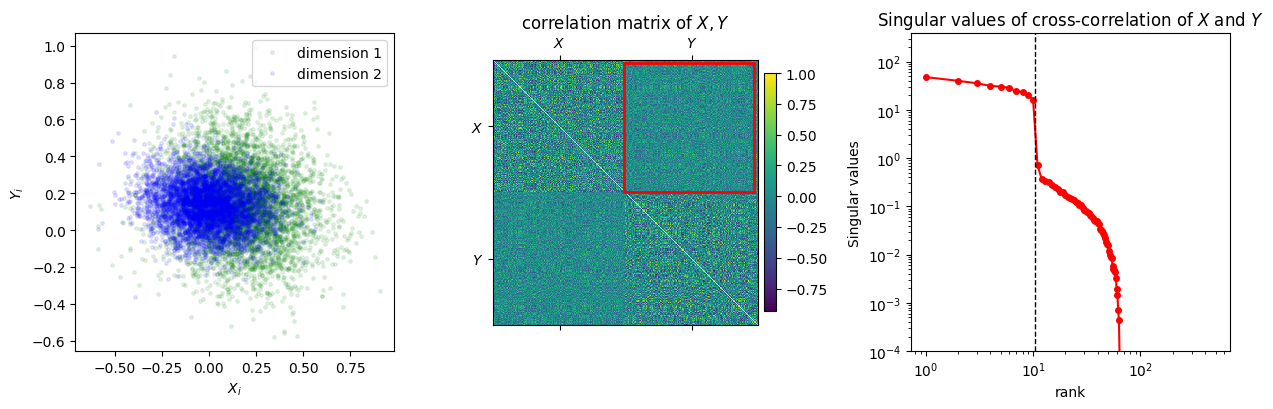

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))

r01 = np.corrcoef(x_big[:, 0], y_big[:, 0])[0, 1]
axes[0].plot(x_big[:, 0], y_big[:, 0], '.', ms=5, alpha=0.1, color='g', label='dimension 1')
axes[0].plot(x_big[:, 1], y_big[:, 1], '.', ms=5, alpha=0.1, color='b', label='dimension 2')
axes[0].set_ylabel('$Y_i$')
axes[0].set_xlabel('$X_i$')
axes[0].legend()

cor_matrix = np.corrcoef(x_big.T, y_big.T)
axes[1].matshow(cor_matrix, cmap='viridis')
plt.colorbar(axes[1].images[0], ax=axes[1], shrink=0.75, pad=0.02)
from matplotlib.patches import Rectangle
axes[1].add_patch(Rectangle((495, 10), 490, 490, fill=False, color='r', lw=2))
axes[1].set_title(r'correlation matrix of $X, Y$')
axes[1].set_xticks([250, 750])
axes[1].set_xticklabels([r'$X$', r'$Y$'])
axes[1].set_yticks([250, 750])
axes[1].set_yticklabels([r'$X$', r'$Y$'])

sv = np.linalg.svd(cor_matrix[OBSERVED_DIM:, :OBSERVED_DIM], compute_uv=False)
axes[2].plot(np.arange(1, OBSERVED_DIM+1), sv, 'o-', ms=4, color='r')
axes[2].axvline(LATENT_DIM + 0.5, color='k', ls='--', lw=1)
axes[2].set_xlabel('rank')
axes[2].set_ylabel('Singular values')
axes[2].set_title(f'Singular values of cross-correlation of $X$ and $Y$')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_ylim(bottom=1e-4)
fig.tight_layout()
plt.show()

The panels shouldn't be a surprise if you know how the data was made. Nobody
knows that about a real recording.
- **Left:** Any single pair of channels looks like a
blob, so there is nothing to find one pair at a time.
- **Centre:** The correlation matrix shows some structure inside $X$ and inside
$Y$, and nothing at all in the shared block outlined in red.
- **Right:** The singular values of the shared part drop by orders of magnitude
after the tenth component, so the five hundred
channels are ten directions and some noise. An estimator that works in the
ambient space is being asked to handle five hundred dimensions to reach ten
dimensions of structure.

KSG has one free parameter, the neighbour count $k$. Too small is noisy, and
too large breaks the local-density assumption while costing more to compute. In
low dimensions you can sweep it and read off a plateau, if any, and extrapolate to the correct MI value.

In [11]:
# `bmi` is an optional dependency of this notebook and not of the library. When
# it is absent the cell reports the comparison in text and the notebook
# continues.

try:
    import bmi
except ImportError:
    bmi = None

ksg = {}
if bmi is None:
    print("bmi is not installed, so this cell describes the KSG result without running it.")
    print("Install it with `pip install benchmark-mi` to reproduce this sweep.")
    print()
    print(f"What it shows: on this problem ({OBSERVED_DIM} observed dimensions over a")
    print(f"{LATENT_DIM}-dimensional shared latent, exact MI {MI_TRUE:.1f} bits), KSG stays")
    print("well below the truth at every neighbour count tested, at both sample")
    print("sizes, and the estimate drifts with k and never settles on a plateau.")
else:
    for n in COMPARE_NS:
        xh, yh = data[n]
        ksg[n] = {}
        for k in KSG_K:
            t0 = time.time()
            est_nats = bmi.estimators.KSGEnsembleFirstEstimator(
                neighborhoods=(k,)).estimate(xh, yh)
            ksg[n][k] = est_nats / np.log(2)   # bmi reports nats
            print(f"N={n:>6,}  k={k:>3}  MI={ksg[n][k]:>6.3f} bits  "
                  f"({time.time() - t0:.1f}s)", flush=True)

N=   500  k=  3  MI= 1.307 bits  (0.6s)


N=   500  k=  5  MI= 1.173 bits  (1.1s)


N=   500  k= 10  MI= 1.003 bits  (0.4s)


N=   500  k= 20  MI= 0.823 bits  (0.3s)


N=   500  k= 40  MI= 0.617 bits  (0.3s)


N= 5,000  k=  3  MI= 2.086 bits  (36.8s)


N= 5,000  k=  5  MI= 1.951 bits  (26.3s)


N= 5,000  k= 10  MI= 1.771 bits  (40.6s)


N= 5,000  k= 20  MI= 1.572 bits  (35.3s)


N= 5,000  k= 40  MI= 1.378 bits  (33.1s)


The estimate moves with $k$ and never approaches the truth at either sample
size (plotted below). There is no plateau to extrapolate to and no value of $k$
a reader could have chosen in advance. More samples help in principle but in
this case they do not close the gap.

KSG is a strong estimator up to ~10 dimensions, but once the ambient
dimensionality is high, the neighbour distances stop being informative whatever
the latent structure underneath is.

## 4. A neural estimator

A neural estimator gets its leverage by learning a map from each variable into
a low-dimensional embedding and estimating the information in those embeddings.
What then has to be estimated well is the structure, so the cost follows what
the data contains instead of how many channels it arrived on. Neural networks
also let us adapt the way those embeddings are built to whatever data we are
handed. The sampling requirement follows the low-dimensional space, so ten
latent dimensions are in principle estimable from five hundred samples where
the ambient five hundred dimensions are not.

We repeat the estimation with neural estimators on the data we just looked at, with the same call that measured the folded pair in section 1.

In [12]:
neural = {}
for n in COMPARE_NS:
    xh, yh = data[n]
    t0 = time.time()
    res = estimate(xh, yh)
    neural[n] = res
    print(f"N={n:>6,}   NeuralMI mode='estimate'   MI = {res.mi_estimate:.3f} bits   "
          f"(exact {MI_TRUE:.1f}, {time.time() - t0:.1f}s)", flush=True)

Run 6f0b616d-0463-49c2-aa24-2a37eb15a2da_c0:   0%|          | 0/150 [00:00<?, ?it/s]

N=   500   NeuralMI mode='estimate'   MI = 4.388 bits   (exact 4.0, 3.2s)


Run 3ba9d081-8665-462b-bf27-19aa53664b28_c0:   0%|          | 0/150 [00:00<?, ?it/s]

N= 5,000   NeuralMI mode='estimate'   MI = 3.934 bits   (exact 4.0, 11.5s)


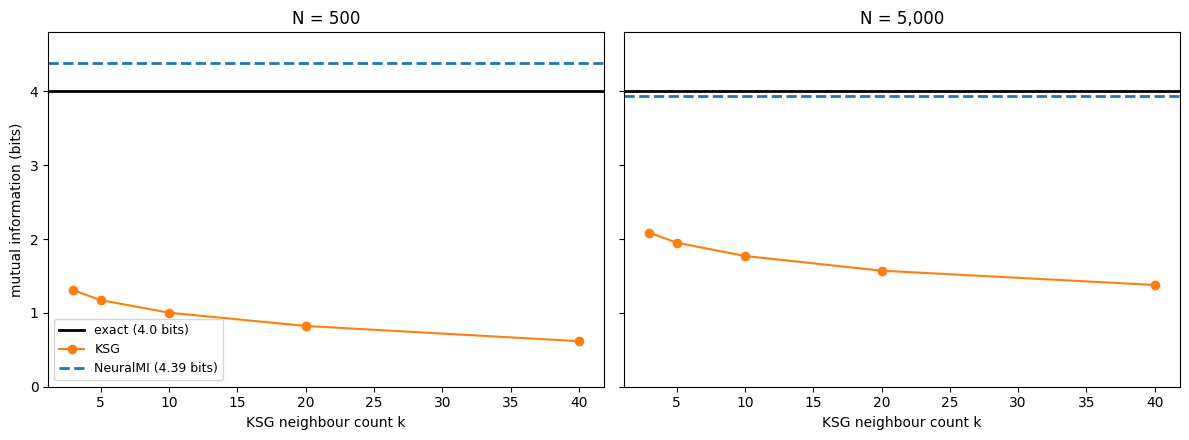

In [13]:
fig, axes = plt.subplots(1, len(COMPARE_NS), figsize=(6 * len(COMPARE_NS), 4.5),
                         sharey=True, squeeze=False)
for ax, n in zip(axes[0], COMPARE_NS):
    ax.axhline(MI_TRUE, color='k', lw=2, label=f'exact ({MI_TRUE:.1f} bits)')
    if ksg:
        ax.plot(list(ksg[n]), list(ksg[n].values()), 'o-', color='tab:orange',
                label='KSG')
    ax.axhline(neural[n].mi_estimate, color='tab:blue', ls='--', lw=2,
               label=f'NeuralMI ({neural[n].mi_estimate:.2f} bits)')
    ax.set_title(f'N = {n:,}')
    ax.set_xlabel('KSG neighbour count k')
axes[0][0].set_ylabel('mutual information (bits)')
axes[0][0].legend(loc='lower left', fontsize=9)
axes[0][0].set_ylim(bottom=0, top=MI_TRUE * 1.2)
fig.tight_layout()
plt.show()

At the larger sample size the neural estimate lands near the truth on a problem
where the classical estimator reaches at most about half the truth at any
neighbour count it was given.

The two sample sizes also show why a trained estimate has to be read with care.
Sample size moves it in two directions at once.

With few samples the network can fit structure that exists only in the
sample. That inflates the estimate and it is the effect behind the
smaller run above. With many samples that fitting error falls away, and what
remains is the lower bound. The estimator can fail to find dependence that is
there and it cannot invent dependence that is not, so the estimate approaches
the true value from underneath. One effect pushes up and grows as the sample
shrinks. The other pulls down and relaxes as the sample grows. Being close to a
known answer is not the same as being right, and on real data you do not have
the known answer to check against. The rest of the series shows how to do the
best we can.

## Where this goes next

Every number in this notebook came out of choices we made for you: the size of
the network, how long it trained, how the sample was split into a part to train
on and a part to evaluate on, and which of the two the reported value is read
from. Each of those could move the answer, and the rest of the series
addresses them.

Notebook 02 takes one estimate apart: what the reported number is, what governs
whether it is any good, and what to check before believing it.